<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/senior/blog_retire_cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pickle

# 저장된 피클 파일 불러오기
with open('blog_retire.pkl', 'rb') as file:
    df = pickle.load(file)

# 데이터 프레임 확인
df

,title,contents,date,token
0,"실버일자리 새로운 시작을 꿈꾸는 법 , 은퇴 후의 보람을 찾는 방법",실버일자리란 무엇인가?실버일자리는 고령자들이 사회에 기여하고 자기 발전을 도모할 수...,2026. 2. 24. 15:46,"[실버, 일자리, 란, 무엇, 실버, 일자리, 고령자, 사회, 기여, 자기, 발전,..."
1,"은퇴 후 일자리, 나만 몰랐던 5060 실버 꿀직장 순위 BEST 4",하루 시간이면 충분해! 등 하원 도우미 스마트폰만 있으면 취업 끝! 데이터 수집가...,2026. 2. 20. 18:22,"[하루, 시간, 이면, 충분하다, 하원, 도우미, 스마트폰, 있다, 취업, 끝, 데..."
2,시니어 경제 편 ​ [2026] 통장에 매달 월급이? 은퇴 후 현금 부자 되는 '노...,최고의 연금 주택연금 활용하기 자식에게 집 한 채는 물려줘야지 라는 생각보다 내 ...,2026. 3. 4. 8:05,"[최고, 연금, 주택연금, 활용, 자식, 집, 생각, 내, 노후, 스스로, 자녀, ..."
3,[공지] 은퇴후 보험료 폭탄 피한 비결? 노후에 장기렌트가 정답인 이유,은퇴 후 보험료 폭탄 피한 비결?노후 차량 장기렌트가 정답인 이유 . 은퇴 세대가 ...,2026. 2. 12. 15:44,"[은퇴, 후, 보험료, 폭탄, 피, 비결, 노후, 차량, 장기, 렌트, 정답, 이유..."
4,과거 은퇴 세대가 꿈꾸던 노후 vs 현재 은퇴 세대가 설계하는 노후,과거 은퇴 세대가 꿈꾸던 노후 현재 은퇴 세대가 설계하는 노후 과거 은퇴 세대가 ...,2025. 12. 16. 16:25,"[과거, 은퇴, 세대, 노후, 현재, 은퇴, 세대, 설계, 노후, 과거, 은퇴, 세..."
...,...,...,...,...
339,노인 평생교육에 대해 알아보자!,고령화의 심화와 노인 평생교육의 필요성노인 평생교육의 역할 국내 노인 평생교육 사례...,2025. 1. 1. 14:00,"[고령화, 심화, 노인, 평생교육, 필요성, 노인, 평생교육, 역할, 국내, 노인,..."
340,잘 넘어지는 사람이 치매에 걸리기 쉽다#건강체조#웃음치료#인지근력운동#건강박수#치매...,함께 해 주신 여러신어렵고 힘들수록작은 것 하나에도웃으며 감사하면건강하고 행복해집니다,2025. 1. 18. 22:05,"[해, 주신, 신, 어렵다, 힘들다, 작다, 하나, 건강하다, 행복하다]"
341,고객 생애 주기와 보험 설계 – 인생 단계별 최적의 보험 선택 가이드,고객 생애 주기와 보험 설계 고객 생애 주기와 보험 설계 인생 단계별 최적의 보험...,2025. 1. 20. 21:40,"[고객, 생애, 주기, 보험, 설계, 고객, 생애, 주기, 보험, 설계, 인생, 단..."
342,경북 영주 시니어 부업 평생 쌓아온 솜씨와 기술 활용으로 경제 활동을 독려해요,시니어의 장점만 살려 경제 활동을 독려면밀하게 검수 후 엄선된 제품 취급문의번호,2025. 1. 21. 14:00,"[시니어, 장점, 경제, 활동, 독려, 면밀하다, 검수, 후, 엄선, 제품, 취급,..."


In [2]:
import json

with open('SentiWord_info.json', encoding= "utf-8-sig", mode = 'r') as f:
  sent_dicts = json.load(f)
sd = {i['word']:int(i['polarity']) for i in sent_dicts}


In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.7 MB/s eta 0:00:00


In [4]:
#필요한 패키지 임포트
import pandas as pd
import gensim
from gensim import corpora, models
from gensim.corpora import Dictionary
from tqdm import tqdm
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt
import numpy as np
tqdm.pandas()

import warnings
warnings.filterwarnings('ignore')

In [10]:
# !pip install gensim

import gensim
from gensim.models.doc2vec import TaggedDocument
from gensim.models import Doc2Vec

tagged_corpus_list = []
for index, row in df.iterrows():
  text = row['token']
  tag = f'document {index}'
  tagged_corpus_list.append(TaggedDocument(tags = [tag], words = text))

d2v_model = Doc2Vec(vector_size=300, window = 5, dm=1)
d2v_model.build_vocab(tagged_corpus_list)
d2v_model.train(tagged_corpus_list, total_examples=d2v_model.corpus_count, epochs = 30)

df['vector'] = [d2v_model.dv.get_vector(f'document {i}') for i in df.index]
df

,title,contents,date,token,vector
0,"실버일자리 새로운 시작을 꿈꾸는 법 , 은퇴 후의 보람을 찾는 방법",실버일자리란 무엇인가?실버일자리는 고령자들이 사회에 기여하고 자기 발전을 도모할 수...,2026. 2. 24. 15:46,"[실버, 일자리, 란, 무엇, 실버, 일자리, 고령자, 사회, 기여, 자기, 발전,...","[0.13120872, -0.16726795, -0.31232426, -0.1199..."
1,"은퇴 후 일자리, 나만 몰랐던 5060 실버 꿀직장 순위 BEST 4",하루 시간이면 충분해! 등 하원 도우미 스마트폰만 있으면 취업 끝! 데이터 수집가...,2026. 2. 20. 18:22,"[하루, 시간, 이면, 충분하다, 하원, 도우미, 스마트폰, 있다, 취업, 끝, 데...","[0.11022013, 0.0708684, 0.006834821, -0.096990..."
2,시니어 경제 편 ​ [2026] 통장에 매달 월급이? 은퇴 후 현금 부자 되는 '노...,최고의 연금 주택연금 활용하기 자식에게 집 한 채는 물려줘야지 라는 생각보다 내 ...,2026. 3. 4. 8:05,"[최고, 연금, 주택연금, 활용, 자식, 집, 생각, 내, 노후, 스스로, 자녀, ...","[-0.033191796, 0.02483655, 0.061711013, -0.039..."
3,[공지] 은퇴후 보험료 폭탄 피한 비결? 노후에 장기렌트가 정답인 이유,은퇴 후 보험료 폭탄 피한 비결?노후 차량 장기렌트가 정답인 이유 . 은퇴 세대가 ...,2026. 2. 12. 15:44,"[은퇴, 후, 보험료, 폭탄, 피, 비결, 노후, 차량, 장기, 렌트, 정답, 이유...","[0.07034563, 0.31960094, 0.012740903, -0.01135..."
4,과거 은퇴 세대가 꿈꾸던 노후 vs 현재 은퇴 세대가 설계하는 노후,과거 은퇴 세대가 꿈꾸던 노후 현재 은퇴 세대가 설계하는 노후 과거 은퇴 세대가 ...,2025. 12. 16. 16:25,"[과거, 은퇴, 세대, 노후, 현재, 은퇴, 세대, 설계, 노후, 과거, 은퇴, 세...","[0.2059571, 0.36908868, 0.13430677, 0.07594152..."
...,...,...,...,...,...
339,노인 평생교육에 대해 알아보자!,고령화의 심화와 노인 평생교육의 필요성노인 평생교육의 역할 국내 노인 평생교육 사례...,2025. 1. 1. 14:00,"[고령화, 심화, 노인, 평생교육, 필요성, 노인, 평생교육, 역할, 국내, 노인,...","[0.03268473, 0.12411448, 0.03414727, 0.2608007..."
340,잘 넘어지는 사람이 치매에 걸리기 쉽다#건강체조#웃음치료#인지근력운동#건강박수#치매...,함께 해 주신 여러신어렵고 힘들수록작은 것 하나에도웃으며 감사하면건강하고 행복해집니다,2025. 1. 18. 22:05,"[해, 주신, 신, 어렵다, 힘들다, 작다, 하나, 건강하다, 행복하다]","[0.030126475, 0.014375776, 0.019331736, 0.0143..."
341,고객 생애 주기와 보험 설계 – 인생 단계별 최적의 보험 선택 가이드,고객 생애 주기와 보험 설계 고객 생애 주기와 보험 설계 인생 단계별 최적의 보험...,2025. 1. 20. 21:40,"[고객, 생애, 주기, 보험, 설계, 고객, 생애, 주기, 보험, 설계, 인생, 단...","[0.29908845, 1.0340257, -0.32764065, -0.010744..."
342,경북 영주 시니어 부업 평생 쌓아온 솜씨와 기술 활용으로 경제 활동을 독려해요,시니어의 장점만 살려 경제 활동을 독려면밀하게 검수 후 엄선된 제품 취급문의번호,2025. 1. 21. 14:00,"[시니어, 장점, 경제, 활동, 독려, 면밀하다, 검수, 후, 엄선, 제품, 취급,...","[0.01141845, 0.076822266, 0.005344295, -0.0475..."


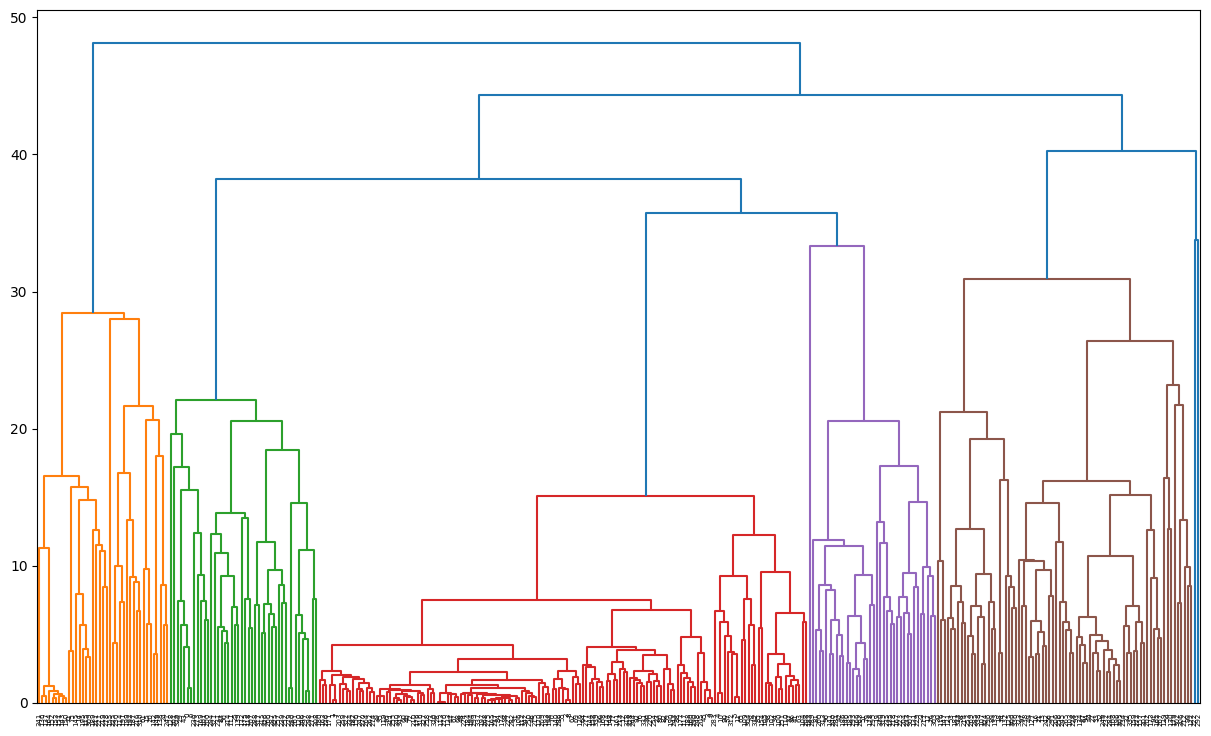

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

#dendrogram 시각화로 적절한 클러스터 사이즈를 예측해본다
#method="ward" -> 거리가 아닌 밀도기반
linked = linkage(list(df['vector']), method="ward")
plt.figure(figsize=(15,9))
dendrogram(linked)
plt.show()

100%|██████████| 9/9 [00:00<00:00, 13.86it/s]


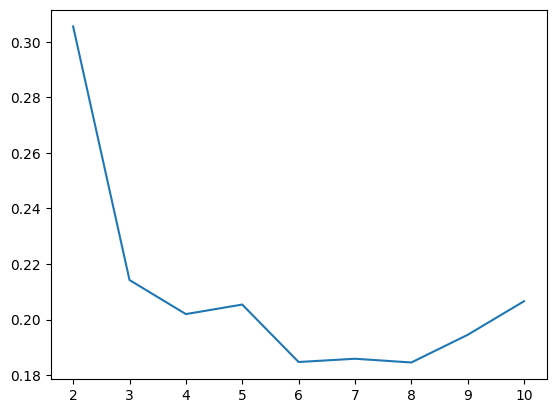

In [12]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# try 2-10 clusters and visualize score
scores = []
for i in tqdm(range(2,11)):
  agg = AgglomerativeClustering(n_clusters = i, linkage = 'ward')
  prediction = agg.fit_predict(list(df['vector']))
  score = silhouette_score(list(df['vector']),prediction)
  scores.append(score)

plt.plot(range(2,11),scores)

# elbow point 튀어오르는 포인트
# 실루엣 점수가 제일 높은 경우를 따라서 갈 수도 있지만 수학적 기반이고 임의로 엘보우 포인트를 정하기도 한다

In [19]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters = 5, linkage = 'ward')
df['cluster'] = agg.fit_predict(list(df['vector']))
df

#너무 적은 클러스터가 없는지 확인해보기
#df['cluster'].value_counts()

,title,contents,date,token,vector,cluster
0,"실버일자리 새로운 시작을 꿈꾸는 법 , 은퇴 후의 보람을 찾는 방법",실버일자리란 무엇인가?실버일자리는 고령자들이 사회에 기여하고 자기 발전을 도모할 수...,2026. 2. 24. 15:46,"[실버, 일자리, 란, 무엇, 실버, 일자리, 고령자, 사회, 기여, 자기, 발전,...","[0.13120872, -0.16726795, -0.31232426, -0.1199...",4
1,"은퇴 후 일자리, 나만 몰랐던 5060 실버 꿀직장 순위 BEST 4",하루 시간이면 충분해! 등 하원 도우미 스마트폰만 있으면 취업 끝! 데이터 수집가...,2026. 2. 20. 18:22,"[하루, 시간, 이면, 충분하다, 하원, 도우미, 스마트폰, 있다, 취업, 끝, 데...","[0.11022013, 0.0708684, 0.006834821, -0.096990...",0
2,시니어 경제 편 ​ [2026] 통장에 매달 월급이? 은퇴 후 현금 부자 되는 '노...,최고의 연금 주택연금 활용하기 자식에게 집 한 채는 물려줘야지 라는 생각보다 내 ...,2026. 3. 4. 8:05,"[최고, 연금, 주택연금, 활용, 자식, 집, 생각, 내, 노후, 스스로, 자녀, ...","[-0.033191796, 0.02483655, 0.061711013, -0.039...",0
3,[공지] 은퇴후 보험료 폭탄 피한 비결? 노후에 장기렌트가 정답인 이유,은퇴 후 보험료 폭탄 피한 비결?노후 차량 장기렌트가 정답인 이유 . 은퇴 세대가 ...,2026. 2. 12. 15:44,"[은퇴, 후, 보험료, 폭탄, 피, 비결, 노후, 차량, 장기, 렌트, 정답, 이유...","[0.07034563, 0.31960094, 0.012740903, -0.01135...",0
4,과거 은퇴 세대가 꿈꾸던 노후 vs 현재 은퇴 세대가 설계하는 노후,과거 은퇴 세대가 꿈꾸던 노후 현재 은퇴 세대가 설계하는 노후 과거 은퇴 세대가 ...,2025. 12. 16. 16:25,"[과거, 은퇴, 세대, 노후, 현재, 은퇴, 세대, 설계, 노후, 과거, 은퇴, 세...","[0.2059571, 0.36908868, 0.13430677, 0.07594152...",0
...,...,...,...,...,...,...
339,노인 평생교육에 대해 알아보자!,고령화의 심화와 노인 평생교육의 필요성노인 평생교육의 역할 국내 노인 평생교육 사례...,2025. 1. 1. 14:00,"[고령화, 심화, 노인, 평생교육, 필요성, 노인, 평생교육, 역할, 국내, 노인,...","[0.03268473, 0.12411448, 0.03414727, 0.2608007...",0
340,잘 넘어지는 사람이 치매에 걸리기 쉽다#건강체조#웃음치료#인지근력운동#건강박수#치매...,함께 해 주신 여러신어렵고 힘들수록작은 것 하나에도웃으며 감사하면건강하고 행복해집니다,2025. 1. 18. 22:05,"[해, 주신, 신, 어렵다, 힘들다, 작다, 하나, 건강하다, 행복하다]","[0.030126475, 0.014375776, 0.019331736, 0.0143...",0
341,고객 생애 주기와 보험 설계 – 인생 단계별 최적의 보험 선택 가이드,고객 생애 주기와 보험 설계 고객 생애 주기와 보험 설계 인생 단계별 최적의 보험...,2025. 1. 20. 21:40,"[고객, 생애, 주기, 보험, 설계, 고객, 생애, 주기, 보험, 설계, 인생, 단...","[0.29908845, 1.0340257, -0.32764065, -0.010744...",3
342,경북 영주 시니어 부업 평생 쌓아온 솜씨와 기술 활용으로 경제 활동을 독려해요,시니어의 장점만 살려 경제 활동을 독려면밀하게 검수 후 엄선된 제품 취급문의번호,2025. 1. 21. 14:00,"[시니어, 장점, 경제, 활동, 독려, 면밀하다, 검수, 후, 엄선, 제품, 취급,...","[0.01141845, 0.076822266, 0.005344295, -0.0475...",0


In [22]:
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

all_document = []
for i in df['cluster'].unique():
  temp = df.loc[df['cluster'] == i]['token']
  cluster_document = ''
  for w in temp:
    doc = " ".join(w)+' '
    cluster_document+=doc
  all_document.append(cluster_document)
all_document[0]


'실버 일자리 란 무엇 실버 일자리 고령자 사회 기여 자기 발전 도모 있다 직업 의미 최근 은퇴 후 업무 통해 보람 수요 증가 개념 더욱 주목 있다 나이 많다 여전하다 많다 경험 지혜 가지 있다 어르신 활발하다 사회 참여 있다 기회 제공 실버 일자리 대표 예 자원봉사 재택근무 상담 및 교육 분야 일자리 있다 나이 단지 숫자일 뿐 나이 단지 숫자일 뿐 실버 일자리 새롭다 시작 기회 제공 많다 은퇴 자 자신 온 지식 경험 활용 감 사회 긍정 기여 이러하다 과정 개인 성취 감 아니다 주변 긍정 영향 미치다 기도 예 사회 기업 일자리 사회 센터 자원봉사 어르신 지혜 젊다 세대 좋다 기회 은퇴 후 보람 찾기 은퇴 후 보람 방법 다양하다 첫째 자신 좋아하다 분야 새롭다 도전 시작 이다 예 원예 공예 봉사활동 있다 이러하다 활동 단순하다 일자리 이상 소중하다 경험 인간 관계 형성 데 도움 둘째 자신 관심사 실버 일자리 탐색 중요하다 취업 웹사이트 정부 기관 지원 프로그램 통해 실버 일자리 정보 손쉽다 있다 경험 나이 상관없다 경험 나이 상관없다 네트워킹 통한 다양하다 기회 좋다 방법 이다 같다 관심사 교류 새롭다 경험 지식 기회 제공 커뮤니티 강좌 워크샵 참여 다양하다 프로그램 일자리 대한 정보 있다 이러하다 모임 새롭다 인연 실버 일자리 관 유용하다 팁 공유 있다 실버 일자리 장점 실버 일자리 가장 장점 개인 자아 실현 사회 기여 이다 실버 일자리 통해 은퇴 자 자신 역량 발휘 사회 긍정 영향 미치다 있다 또한 동료 만남 통해 외로움 극복 새롭다 친구 있다 기회 통해 건강하다 행복하다 노후 있다 실버 일자리 단순하다 경제 필요 충족 이상 의미 은퇴 후 다양하다 방법 보람 새롭다 시작 있다 기회 제공 이러하다 변화 실버 대가 자신 경험 기반 사회 기여 있다 멋지다 기회 이다 실제 많다 은퇴 실버 일자리 통해 마음 안정 삶 질 향상 경험 있다 당신 앞 삶 새롭다 시작 실버 일자리 도전 실버 일자리 란 무엇 실버 일자리 고령자 사회 기여 자기 발전 도모 있다 직업 의미 최근 

In [24]:
#tf-idf vectorizer
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(all_document)

#transform to dataFrame
feature_names = vectorizer.get_feature_names_out() #vocab
tfidf = tfidf.toarray()


tfidf = pd.DataFrame(tfidf, columns = feature_names)
tfidf = tfidf.transpose() #swap row - col
tfidf

,0,1,2,3,4
가게,0.001463,0.000000,0.001162,0.000000,0.003211
가격,0.001041,0.001823,0.001654,0.008399,0.009140
가계,0.000000,0.006175,0.000000,0.002370,0.000000
가계부,0.000000,0.000000,0.001400,0.001185,0.000000
가계부채,0.000000,0.003827,0.000000,0.000000,0.000000
...,...,...,...,...,...
힘껏,0.000000,0.000000,0.001736,0.000000,0.000000
힘드다,0.001230,0.003234,0.002934,0.000000,0.002701
힘들다,0.001230,0.007546,0.020536,0.000000,0.013507
힘차다,0.000000,0.001544,0.001400,0.000000,0.000000


In [36]:

for i in tfidf.columns:
  cluster = tfidf.sort_values(by=i,ascending = False)
  print(f'===========cluster{i}===========')
  print(cluster[i].head(15))
  print(f'===========cluster{i}===========')

===========cluster0===========
있다     0.497460
시니어    0.294079
사회     0.220631
이다     0.212305
일자리    0.200564
활동     0.160270
실버     0.155066
어르신    0.118124
건강     0.112397
교육     0.104589
골프     0.095074
새롭다    0.093664
노인     0.091583
세대     0.091583
활용     0.091583
Name: 0, dtype: float64
===========cluster0===========
===========cluster1===========
있다     0.441279
사회     0.198758
은퇴     0.198758
노후     0.191464
세대     0.190552
이다     0.153171
시니어    0.150915
경제     0.150436
인구     0.140135
투자     0.134937
노인     0.133113
연금     0.125044
자산     0.116702
고령     0.114264
변화     0.106673
Name: 1, dtype: float64
===========cluster1===========
===========cluster2===========
있다      0.504530
이다      0.286176
은퇴      0.177826
건강      0.166247
운동      0.158419
노후      0.138125
아니다     0.132336
실버      0.120756
시간      0.119102
시니어     0.112458
없다      0.100079
마음      0.096770
시작      0.095116
중요하다    0.090154
좋다      0.089327
Name: 2, dtype: float64
===========cluster2===========
=======

In [37]:
#lda로 토픽 나누기 ** 이번엔 임의로 4개
#필요한 클러스터의 df, model, corpus 리턴
def get_cluster_w_topic(i):
  df_cluster = df.loc[df['cluster'] == i]
  all_documents = list(df_cluster['token'])
  dictionary = Dictionary(all_documents)
  corpus = [dictionary.doc2bow(i) for i in all_documents]

  ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = 4, id2word=dictionary, random_state=42)
  align =[]
  for i in ldamodel.get_document_topics(corpus):
    label = []
    value = []
    for t,v in i:
      label.append(t)
      value.append(v)
    align.append(label[np.argmax(value)])

  df_cluster['topic'] = align

  return (df_cluster, corpus, ldamodel)


def min_max(dic):
  result_dic = {}
  value = list(dic.values())
  minn = np.min(value)
  maxx = np.max(value)

  for k,v in dic.items():
    result_dic[k] = float((v-minn)/(maxx-minn))
  return result_dic

def sentiment_score(sent_dicts, token_list):
  result = [sd[i] for i in token_list if i in sd]
  return 0 if len(result) == 0 else np.mean(result)


In [38]:
def get_sents(df):
  df['sentiment'] = df['token'].apply(lambda x: sentiment_score(sd,x))

  action_sents = {}
  for i in df['topic'].unique():
    action_sents[int(i)] = float(np.mean(df.loc[df['topic'] == i]['sentiment']))

  normalized_action_sents = min_max(action_sents)
  print('sentiment', normalized_action_sents)
  return normalized_action_sents

In [39]:
def get_imps(ldamodel, corpus):
  prob = []
  for i in ldamodel.get_document_topics(corpus):
    temp = {i:0 for i in range(4)}
    for k,v in i:
      temp[k] = float(v)
    prob.append(list(temp.values()))

  value = np.array(prob).mean(axis=0)
  action_imp = {}
  for i in range(len(prob[0])):
    action_imp[i] = float(value[i])

  normalized_action_imp = min_max(action_imp)
  print('importance',normalized_action_imp)
  return normalized_action_imp

In [41]:
def get_opp(normalized_action_sents,normalized_action_imp):
  opportunity_score = {}
  for i in range(4):
    sat = normalized_action_sents[i]
    imp = normalized_action_imp[i]

    opportunity_score[i] = imp + float(np.max([imp-sat,0]))

  print('opportunity',opportunity_score)
  return opportunity_score

In [60]:
import pickle
all_res = []
# for i in df['cluster'].unique():
for i in [4,0,1,3]:
  df_cluster, corpus, ldamodel = get_cluster_w_topic(i)
  sent = get_sents(df_cluster)
  imp = get_imps(ldamodel,corpus)
  opp = get_opp(sent, imp)
  all_res.append((int(i),sent,imp,opp))
  #save pkl file
  with open(f'cluster{i}.pkl','wb') as file:
    pickle.dump(df_cluster,file)

sentiment {3: 0.7127276367411612, 1: 0.0, 2: 0.3783638740889497, 0: 1.0}
importance {0: 0.2708571727875788, 1: 1.0, 2: 0.0, 3: 0.7682984000965544}
opportunity {0: 0.2708571727875788, 1: 2.0, 2: 0.0, 3: 0.8238691634519475}
sentiment {1: 1.0, 3: 0.0, 2: 0.37370097133908925, 0: 0.5862220869014285}


importance {0: 0.42938720935689, 1: 1.0, 2: 0.46944128769713594, 3: 0.0}
opportunity {0: 0.42938720935689, 1: 1.0, 2: 0.5651816040551827, 3: 0.0}
sentiment {1: 0.6862586670958154, 0: 1.0, 2: 0.0, 3: 0.673206865134612}
importance {0: 0.8345014388267366, 1: 1.0, 2: 0.835517486214098, 3: 0.0}
opportunity {0: 0.8345014388267366, 1: 1.3137413329041845, 2: 1.671034972428196, 3: 0.0}


sentiment {0: 0.7734883846236047, 3: 1.0, 2: 0.9486745371741832, 1: 0.0}
importance {0: 0.8730565212671633, 1: 0.40775770856326854, 2: 1.0, 3: 0.0}
opportunity {0: 0.9726246579107218, 1: 0.8155154171265371, 2: 1.0513254628258168, 3: 0.0}


In [47]:
all_res

[(4,
  {3: 0.7127276367411612, 1: 0.0, 2: 0.3783638740889497, 0: 1.0},
  {0: 0.2708571727875788, 1: 1.0, 2: 0.0, 3: 0.7682984000965544},
  {0: 0.2708571727875788, 1: 2.0, 2: 0.0, 3: 0.8238691634519475}),
 (0,
  {1: 1.0, 3: 0.0, 2: 0.37370097133908925, 0: 0.5862220869014285},
  {0: 0.42938720935689, 1: 1.0, 2: 0.46944128769713594, 3: 0.0},
  {0: 0.42938720935689, 1: 1.0, 2: 0.5651816040551827, 3: 0.0}),
 (1,
  {1: 0.6862586670958154, 0: 1.0, 2: 0.0, 3: 0.673206865134612},
  {0: 0.8345014388267366, 1: 1.0, 2: 0.835517486214098, 3: 0.0},
  {0: 0.8345014388267366,
   1: 1.3137413329041845,
   2: 1.671034972428196,
   3: 0.0}),
 (3,
  {0: 0.7734883846236047, 3: 1.0, 2: 0.9486745371741832, 1: 0.0},
  {0: 0.8730565212671633, 1: 0.40775770856326854, 2: 1.0, 3: 0.0},
  {0: 0.9726246579107218,
   1: 0.8155154171265371,
   2: 1.0513254628258168,
   3: 0.0})]

In [48]:
sents_df = pd.DataFrame(columns = ['action','satisfaction', 'importance','opportunity'])
for cluster in all_res:
  idx = cluster[0]
  sents = cluster[1]
  imp = cluster[2]
  opp = cluster[3]
  for i in range(4):
    sents_df.loc[len(sents_df)] = [f'cluster{idx}action{i}',sents[i],imp[i],opp[i]]

sents_df

,action,satisfaction,importance,opportunity
0,cluster4action0,1.000000,0.270857,0.270857
1,cluster4action1,0.000000,1.000000,2.000000
2,cluster4action2,0.378364,0.000000,0.000000
3,cluster4action3,0.712728,0.768298,0.823869
4,cluster0action0,0.586222,0.429387,0.429387
5,cluster0action1,1.000000,1.000000,1.000000
6,cluster0action2,0.373701,0.469441,0.565182
7,cluster0action3,0.000000,0.000000,0.000000
8,cluster1action0,1.000000,0.834501,0.834501
9,cluster1action1,0.686259,1.000000,1.313741


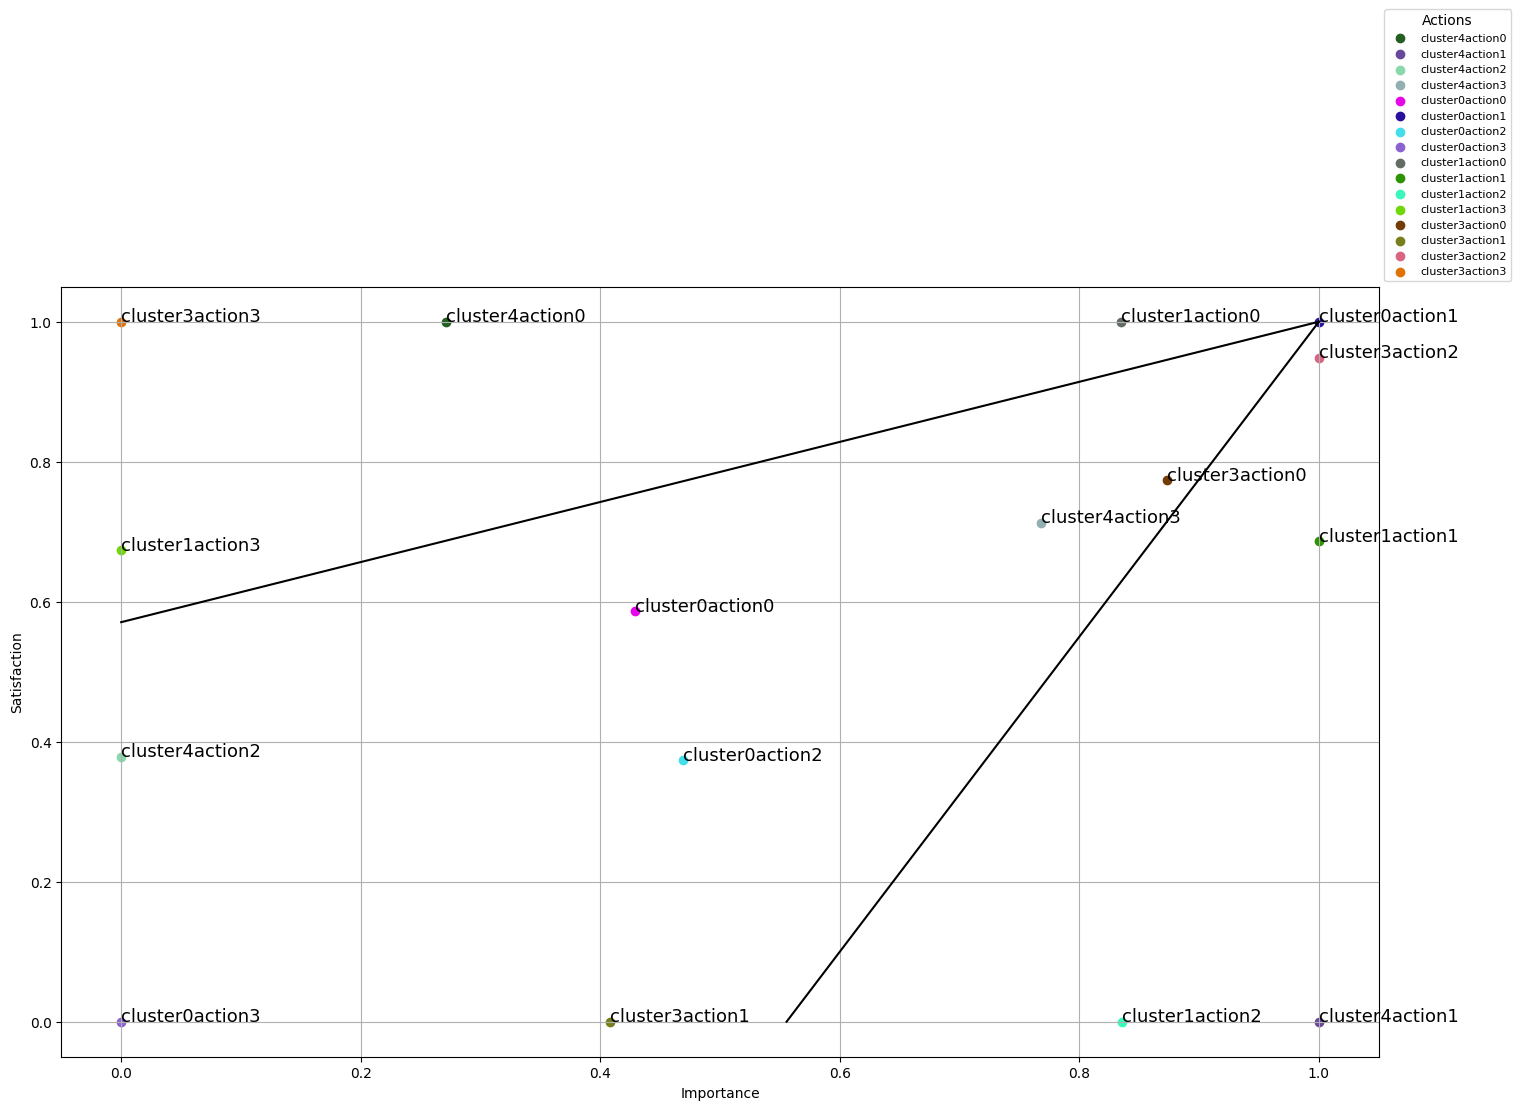

In [49]:
actions = sents_df['action']
colors = np.random.rand(len(actions),3) #rgb내에서 리스트 길이만큼 랜덤 색깔 선택
imp = sents_df['importance']
sat = sents_df['satisfaction']

plt.figure(figsize=(17,10))

for i, action in enumerate(actions):
  plt.scatter(imp[i],sat[i],c = [colors[i]],label= action)

plt.legend(title='Actions', fontsize = 8, title_fontsize = 10, loc='best',bbox_to_anchor = (1,1))
plt.xlabel('Importance')
plt.ylabel('Satisfaction')

#만족도 기준선
x_data = [0,1]
y_data = [sat.mean(),1]
plt.plot(x_data, y_data, 'k-')

#중요도 기준선
x_data = [imp.mean(),1]
y_data = [0,1]
plt.plot(x_data, y_data, 'k-')

#legend for each point
texts = []
for i, action in enumerate(actions):
  texts.append(plt.text(imp[i], sat[i], action, fontsize = 13))

plt.grid(True)
plt.savefig('Opportunity area.png', dpi=300, bbox_inches='tight')

In [77]:
c4 = pd.read_pickle('cluster4.pkl')
c4.loc[c4['topic']==1]

,title,contents,date,token,vector,cluster,sentiment,topic
25,"은퇴후 자격증, 창원실버카페 바리스타 도전기",안녕하세요 창원 퍼스트 바리스타학원입니다 ! 창원실버카페 조금 오글 거릴 수 있지만...,2025. 5. 19. 17:06,"[안녕하다, 창원, 퍼스트, 바리스타, 학원, 이다, 창원, 실버, 카페, 조금, ...","[0.22688068, -0.046685874, 0.07561007, -0.5651...",4,0.533333,1
83,안양시노인종합복지관 노년사회화교육,안양시에서 배울 수 있는 프로그램을추천드립니다. 안양시노인종합복지관노년사회화교육은퇴...,2025. 11. 6. 11:39,"[안양시, 있다, 프로그램, 추천, 안양시, 노인, 종합, 복지관, 노년, 사회, ...","[0.8798479, 0.18489383, -0.24023919, -0.095889...",4,1.333333,1
101,2026년 부산금정시니어클럽 일자리 완벽 가이드: 미리 보고 준비하세요!,서론 활기찬 노후 년 부산금정시니어클럽 일자리에서 시작됩니다 세 시대가 현실로...,2026. 1. 4. 14:29,"[서론, 활기차다, 노후, 부산, 금정, 시니어, 클럽, 일자리, 시작, 세, 시대...","[0.53890455, 0.6201265, -0.16724639, -0.402123...",4,1.107143,1
175,🕒 [초특급 기회] 1년 안에 '3 in 1' 자격증 3개 동시 취득! 노후 준비 끝판왕,안녕하세요! 세 시대 은퇴 후의 삶을 고민하고 계신가요?단 년이라는 짧은 시간 안...,2026. 1. 2. 20:22,"[안녕하다, 세, 시대, 은퇴, 후의, 삶, 고민, 계시다, 단, 짧다, 시간, 안...","[0.5949768, 0.40291557, -0.24388944, -0.702731...",4,0.350000,1
231,디지털 격차 해소를 위한 세대 간 기술 전수 프로젝트 성과,디지털 격차 해소를 위한 세대 간 기술 전수 프로젝트 성과어르신들이 스마트폰과 컴퓨...,2025. 7. 25. 8:00,"[디지털, 격차, 해소, 위, 세대, 간, 기술, 전수, 프로젝트, 성과, 어르신,...","[0.40683404, -0.38106897, -0.023464048, -0.419...",4,1.136364,1
239,"100세 시대, 소비는 선택이 아니라 전략입니다",당신의 소비는 몇 살까지를 내다보고 있나요? 예전엔 은퇴를 앞두고 소비를 줄이는 게...,2025. 6. 29. 20:57,"[당신, 소비, 몇, 살, 있다, 예전, 은퇴, 소비, 당연하다, 이제, 다르다, ...","[1.2806427, 0.35639703, -0.16872232, -0.806616...",4,-0.105263,1
252,"실버산업 아이템, 100세 시대의 기회는 지금이다!",고령화 사회가 빠르게 다가오고 있어요. 요즘 뉴스를 보면 초고령 사회 라는 단어가 ...,2025. 4. 8. 13:08,"[고령화, 사회, 빠르다, 있다, 요즘, 뉴스, 초, 고령, 사회, 단어, 익숙하다...","[0.50858396, 0.116210915, 0.25899205, -0.33765...",4,0.517241,1
257,"비트버니 퀴즈 'ㅅㅍㅇㅇㅈ' 정답은? 초고령화 사회 슈퍼에이지, 우리 삶에 미치는 영향",안녕하세요 여러분!혹시 매일 새로운 지식을 얻고 포인트도 쌓는 재미에 푹 빠져 계신...,2025. 9. 16. 4:38,"[안녕하다, 여러분, 혹시, 매일, 새롭다, 지식, 포인트, 재미, 푹, 계시다, ...","[-0.04394278, -0.49858394, 0.41492146, 0.30902...",4,1.052632,1
266,강남시니어플라자 시니어는 무조건 참여하는게 이득!!,강남시니어플라자 시니어는 무조건 참여하는게 이득!! 최근 서울 강남 지역의 시니어 ...,2025. 8. 5. 14:01,"[강남, 시니어, 플라자, 시니어, 무조건, 참여, 이득, 최근, 서울, 강남, 시...","[0.51614994, 0.6038519, -0.07863202, -0.115320...",4,1.190476,1
271,"2032년 우리의 집, 어떻게 달라질까? 제3차 장기 주거종합계획 정리",대한민국의 주거 환경이 크게 달라질 전망입니다. 정부는 제 차 장기 주거종합계획 을...,2025. 7. 8. 16:14,"[대한민국, 주거, 환경, 크게, 전망, 이다, 정부, 차, 장기, 주거, 종합, ...","[0.36794174, 0.7906716, -0.25093535, 1.0540707...",4,0.000000,1


In [74]:
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

all_document = []
for i in c4['topic'].unique():
  temp = c4.loc[c4['topic'] == i]['token']
  cluster_document = ''
  for w in temp:
    doc = " ".join(w)+' '
    cluster_document+=doc
  all_document.append(cluster_document)
all_document[0]


'안녕하다 오늘 실버 세대 분 위 노후 준비 법 대해 이야기 해 요즘 은퇴 후 활기차다 행복하다 삶 분 많다 그렇다 어떻다 그렇다 삶 있다 첫 번 재정 계획 정말 중요하다 은퇴 후 수입 미리 저축 해 필수 이다 예 연금 개인 연금 상품 가입 도움 거 걸 왜 미리 준비 후회 지금 시작 두 번 건강 관리 없다 나이 건강 가장 자산 요 규칙 운동 균형 식사 필수 이다 요즘 걷기 요가 수영 다양하다 운동 프로그램 있다 자신 운동 재밌다 줄 있다 거 세 번 사회 관계 유지 중요하다 친구 만남 동호회 활동 통해 소통 어가 외로움 덜 있다 많다 있다 정말 행복하다 기분 마지막 취미 생활 그림 그리기 정원 여행 다양하다 취미 통해 삶 질 있다 이렇다 재미있다 있다 새롭다 발견 여러분 있다 거 결론 실버 세대 노후 준비 재정 건강 사회 관계 취미 여러 가지 요소 조화 해 여러분 행복하다 미래 위해 지금 차근차근 준비 내일 나은 날 긍정 마음가짐 시작 좋다 여러분 멋지다 노후 응원 실버 모델 은퇴 후 활동 변화 세대 소통 이야기 나이 새롭다 도전 변화 맞이 분 점점 있다 은퇴 후 이전 다른 생활 패턴 자신 시간 어떻다 활용 고민 과정 실버 모델 활동 시작 거나 다양하다 사회 참여 통해 활 경우 이번 글 그렇다 변화 세대 간 소통 어떻다 은퇴 후 새롭다 역할 찾기 직장 뒤 많다 분 갑작스럽다 여유 시간 적응하다 혼란 저 역시 주변 어르신 처음 무상함 호소 다양하다 취미 활동 봉사활동 참여 활기 모습 실버 모델 활동 신체 건강 아니다 정신 만족감 좋다 기회 카메라 앞 자연 포즈 취하 또래 친구 교류 자신감 모습 인상 일상 속 건강 관리 사회 참여 은퇴 후 건강 관리 꾸준하다 무엇 중요하다 규칙 운동 균형 식사 기본 실버 모델 활동 분 자연 몸매 관리 신경 커뮤니티 센터 문화 프로그램 참여 정서 안정 있다 이렇다 경험 단순하다 여가 활동 이상 삶 질 데 도움 같다 세대 간 대화 이해 증진 나이 다른 세대 관계 어려움 경우 적지 서로 경험 생각 만큼 공감 형성 있다 예 젊다 세대 디지

In [75]:
#tf-idf vectorizer
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(all_document)

#transform to dataFrame
feature_names = vectorizer.get_feature_names_out() #vocab
tfidf = tfidf.toarray()


tfidf = pd.DataFrame(tfidf, columns = feature_names)
tfidf = tfidf.transpose() #swap row - col
tfidf

,0,1,2,3
가게,0.004769,0.000000,0.000000,0.000000
가격,0.009539,0.000000,0.000000,0.000000
가계부,0.004769,0.000000,0.000000,0.000000
가구,0.000000,0.003033,0.004037,0.010279
가기,0.000000,0.000000,0.006325,0.000000
...,...,...,...,...
힐즈,0.000000,0.004752,0.000000,0.000000
힘껏,0.000000,0.000000,0.000000,0.008052
힘드다,0.014308,0.000000,0.000000,0.000000
힘들다,0.024889,0.017359,0.006601,0.008404


In [76]:

for i in tfidf.columns:
  cluster = tfidf.sort_values(by=i,ascending = False)
  print(f'===========cluster{i}===========')
  print(cluster[i].head(15))
  print(f'===========cluster{i}===========')

===========cluster0===========
있다     0.555024
이다     0.256356
운동     0.209067
실버     0.156800
세대     0.141867
아니다    0.131911
건강     0.126934
시작     0.124445
은퇴     0.119467
시니어    0.104534
많다     0.102045
같다     0.099556
없다     0.092089
시간     0.092089
근육     0.089600
Name: 0, dtype: float64
===========cluster0===========
===========cluster1===========
있다      0.404227
이다      0.270311
은퇴      0.233112
건강      0.233112
필라테스    0.183590
노후      0.181034
운동      0.138875
강사      0.123642
시간      0.119036
실버      0.116556
마음      0.116556
활동      0.109116
유지      0.104157
중요하다    0.104157
아니다     0.099197
Name: 1, dtype: float64
===========cluster1===========
===========cluster2===========
있다     0.429062
동호회    0.189737
관계     0.181526
이다     0.165024
노후     0.161723
노년     0.155122
전달     0.154580
은퇴     0.151822
가족     0.132019
건강     0.132019
소리     0.129647
없다     0.122118
대화     0.118817
사회     0.105615
어떻다    0.102315
Name: 2, dtype: float64
===========cluster2===========
=======